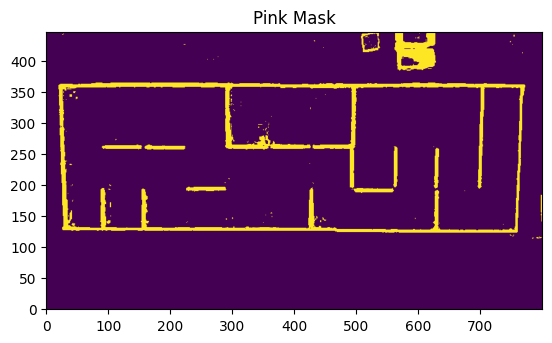

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('../test.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to HSV
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Pink can wrap around the hue range depending on lighting/camera,
# so we use two ranges and combine them.
lower_pink_1 = np.array([140, 60, 60])
upper_pink_1 = np.array([179, 255, 255])

lower_pink_2 = np.array([0, 60, 60])
upper_pink_2 = np.array([7, 255, 255])

mask1 = cv2.inRange(img_hsv, lower_pink_1, upper_pink_1)
mask2 = cv2.inRange(img_hsv, lower_pink_2, upper_pink_2)

pink_mask = cv2.bitwise_or(mask1, mask2)

plt.title("Pink Mask")
plt.imshow(pink_mask)  
plt.axis('on')
plt.gca().invert_yaxis()

Original Box: (x=20, y=123, x2=780, y2=372)


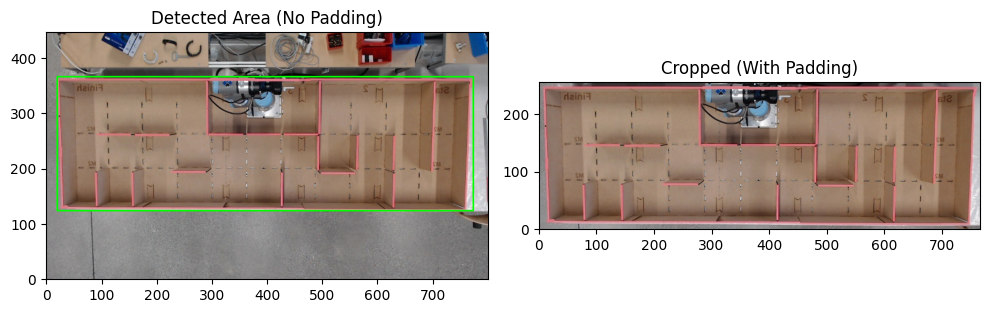

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Find contours from the mask
contours, _ = cv2.findContours(pink_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    # Take the largest contour
    largest_contour = max(contours, key=cv2.contourArea)

    # Bounding box (STRICT detection)
    x, y, w, h = cv2.boundingRect(largest_contour)

    # --- Padding ONLY for cropping ---
    pad = int(0.01 * max(w, h))  # 1% padding

    h_img, w_img = img.shape[:2]

    x1 = max(x - pad, 0)
    y1 = max(y - pad, 0)
    x2 = min(x + w + pad, w_img)
    y2 = min(y + h + pad, h_img)

    print(f"Original Box: (x={x}, y={y}, x2={x2}, y2={y2})")
    # Crop with padding
    cropped = img[y1:y2, x1:x2]

    # Draw ORIGINAL (no padding) bounding box
    img_box = img.copy()
    cv2.rectangle(img_box, (x, y), (x+w, y+h), (0, 255, 0), 2)

    # Convert BGR → RGB
    img_box_rgb = cv2.cvtColor(img_box, cv2.COLOR_BGR2RGB)
    cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)

    # Plot
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.title("Detected Area (No Padding)")
    plt.imshow(img_box_rgb)
    plt.axis('on')
    plt.gca().invert_yaxis()

    plt.subplot(1, 2, 2)
    plt.title("Cropped (With Padding)")
    plt.imshow(cropped_rgb)
    plt.axis('on')
    plt.gca().invert_yaxis()


    plt.tight_layout()
    plt.show()

else:
    print("No pink object detected")

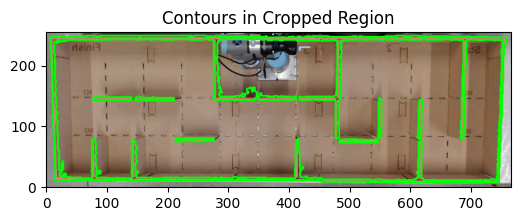

In [6]:
cropped_mask = pink_mask[y1:y2, x1:x2]

contours, _ = cv2.findContours(cropped_mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Keep only large ones
min_area = 200
filtered = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]

cropped_draw = cropped.copy()
k= cv2.drawContours(cropped_draw, filtered, -1, (0, 255, 0), 2)
k = cv2.cvtColor(k, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.title("Contours in Cropped Region")
plt.imshow(k)
plt.axis('on')
plt.gca().invert_yaxis()
plt.show()

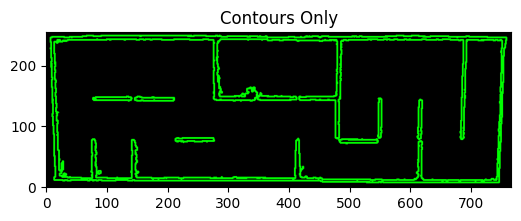

In [7]:
cropped_mask = pink_mask[y1:y2, x1:x2]

contours, _ = cv2.findContours(cropped_mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

min_area = 200
filtered = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]

# Create blank image (black background)
blank = np.zeros_like(cropped)

# Draw contours only
cv2.drawContours(blank, filtered, -1, (0, 255, 0), 2)

# Convert for display
blank_rgb = cv2.cvtColor(blank, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.title("Contours Only")
plt.imshow(blank_rgb)
plt.axis('on')
plt.gca().invert_yaxis()
plt.show()

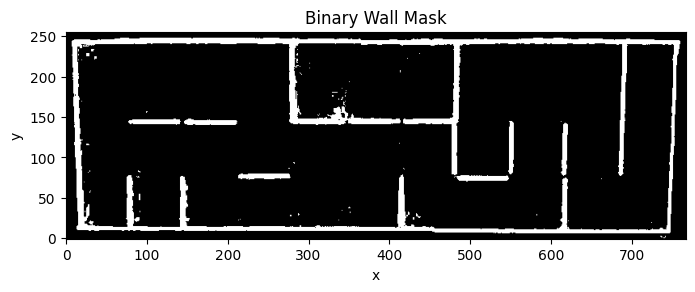

In [8]:
# Binary wall image from pink mask
wall_bin = (cropped_mask > 0).astype(np.uint8) * 255

plt.figure(figsize=(8, 4))
plt.title("Binary Wall Mask")
plt.imshow(wall_bin, cmap="gray", origin="lower")
plt.xlabel("x")
plt.ylabel("y")

plt.show()

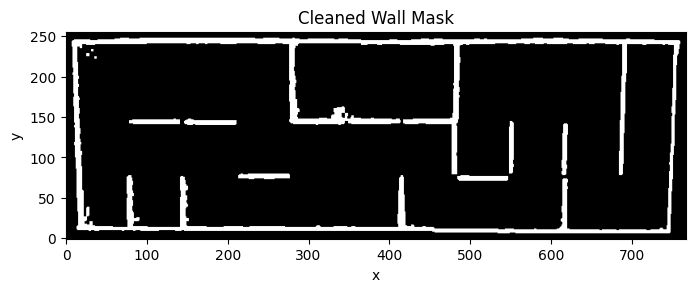

In [9]:
kernel = np.ones((3, 3), np.uint8)

wall_clean = cv2.morphologyEx(wall_bin, cv2.MORPH_OPEN, kernel)
wall_clean = cv2.morphologyEx(wall_clean, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(8, 4))
plt.title("Cleaned Wall Mask")
plt.imshow(wall_clean, cmap="gray", origin="lower")
plt.xlabel("x")
plt.ylabel("y")

plt.show()

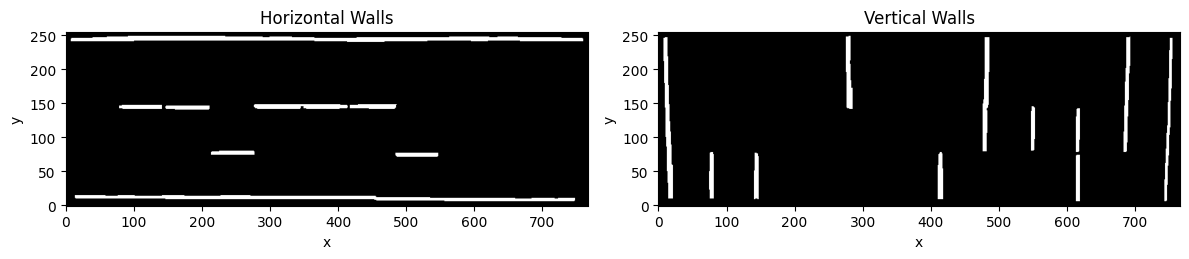

In [10]:
h, w = wall_clean.shape

# Horizontal extraction
h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 1))
horizontal = cv2.morphologyEx(wall_clean, cv2.MORPH_OPEN, h_kernel)

# Vertical extraction
v_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 25))
vertical = cv2.morphologyEx(wall_clean, cv2.MORPH_OPEN, v_kernel)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.title("Horizontal Walls")
plt.imshow(horizontal, cmap="gray", origin="lower")
plt.xlabel("x")
plt.ylabel("y")

plt.subplot(1, 2, 2)
plt.title("Vertical Walls")
plt.imshow(vertical, cmap="gray", origin="lower")
plt.xlabel("x")
plt.ylabel("y")

plt.tight_layout()

plt.show()

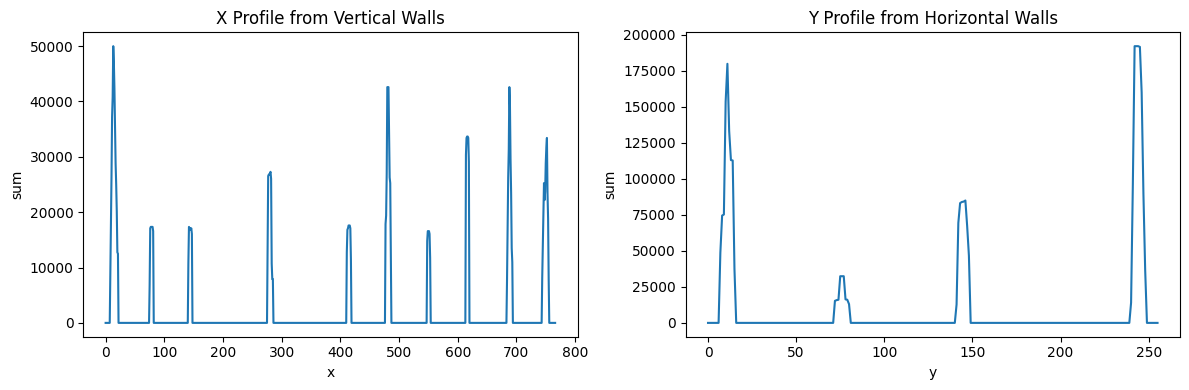

In [11]:
# Projection profiles
x_profile = vertical.sum(axis=0)
y_profile = horizontal.sum(axis=1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.title("X Profile from Vertical Walls")
plt.plot(x_profile)
plt.xlabel("x")
plt.ylabel("sum")

plt.subplot(1, 2, 2)
plt.title("Y Profile from Horizontal Walls")
plt.plot(y_profile)
plt.xlabel("y")
plt.ylabel("sum")

plt.tight_layout()

plt.show()

In [12]:
def extract_peaks(profile, threshold_ratio=0.3, min_gap=15):
    threshold = profile.max() * threshold_ratio
    raw = np.where(profile > threshold)[0]

    if len(raw) == 0:
        return []

    groups = []
    current = [raw[0]]

    for idx in raw[1:]:
        if idx - current[-1] <= min_gap:
            current.append(idx)
        else:
            groups.append(current)
            current = [idx]
    groups.append(current)

    centers = [int(np.mean(g)) for g in groups]
    return centers

x_lines = extract_peaks(x_profile, threshold_ratio=0.3, min_gap=15)
y_lines = extract_peaks(y_profile, threshold_ratio=0.1, min_gap=15)

print("Candidate x grid lines:", x_lines)
print("Candidate y grid lines:", y_lines)

Candidate x grid lines: [14, 78, 144, 279, 414, 481, 550, 616, 688, 750]
Candidate y grid lines: [11, 76, 145, 244]


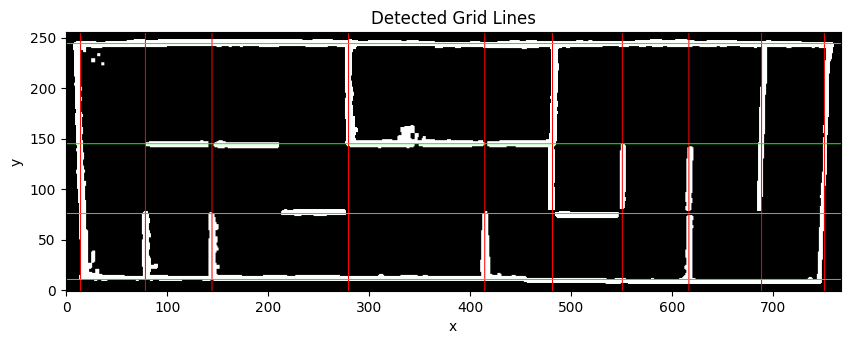

In [13]:
overlay = cv2.cvtColor(wall_clean, cv2.COLOR_GRAY2RGB)

for xg in x_lines:
    cv2.line(overlay, (xg, 0), (xg, h - 1), (255, 0, 0), 1)

for yg in y_lines:
    cv2.line(overlay, (0, yg), (w - 1, yg), (0, 255, 0), 1)

plt.figure(figsize=(10, 5))
plt.title("Detected Grid Lines")
plt.imshow(overlay, origin="lower")
plt.xlabel("x")
plt.ylabel("y")

plt.show()

In [14]:
x_lines = sorted(x_lines)
y_lines = sorted(y_lines)

n_cols = len(x_lines) - 1
n_rows = len(y_lines) - 1

print("Rows:", n_rows, "Cols:", n_cols)

Rows: 3 Cols: 9


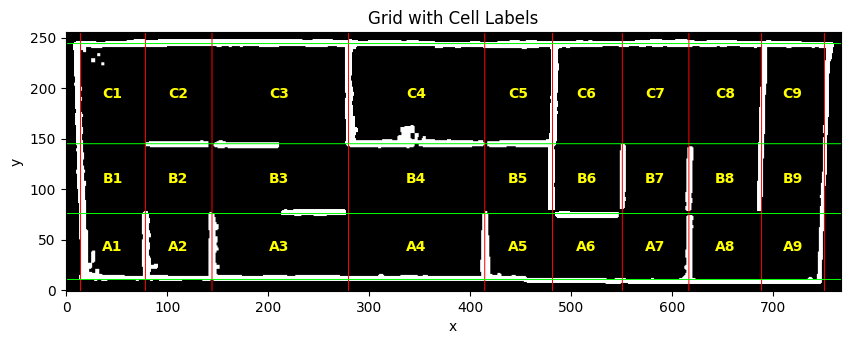

Center of cell A1: (46, 43)
Center of cell B2: (46, 110)
Center of cell C3: (211, 194)


In [15]:
import string

# Create a list for row labels (A, B, C...) and col labels (1, 2, 3...)
row_labels = list(string.ascii_uppercase)[:n_rows] # ['A', 'B', 'C']
col_labels = [str(i+1) for i in range(n_cols)]     # ['1', '2', '3'...]

cell_centers = {}

plt.figure(figsize=(10, 5))
plt.imshow(overlay, origin="lower")

for r in range(n_rows):
    for c in range(n_cols):
        # Calculate center coordinates
        center_x = (x_lines[c] + x_lines[c+1]) // 2
        center_y = (y_lines[r] + y_lines[r+1]) // 2
        
        # Create label (e.g., "A1")
        label = f"{row_labels[r]}{col_labels[c]}"
        cell_centers[label] = (center_x, center_y)
        
        # Plot the label on the image
        plt.text(center_x, center_y, label, color="yellow", 
                 ha="center", va="center", fontweight="bold")

plt.title("Grid with Cell Labels")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# Example: Accessing a specific center
print(f"Center of cell A1: {cell_centers['A1']}")
print(f"Center of cell B2: {cell_centers['B1']}")
print(f"Center of cell C3: {cell_centers['C3']}")



In [16]:
import numpy as np

# Threshold to decide if a line is a wall (0 to 255)
# 127 is a good middle ground for binary images
THRESHOLD = 100 

# Dictionary to store wall data: {(row, col): {'top': True, 'bottom': False, ...}}
grid_walls = {}

for r in range(n_rows):
    for c in range(n_cols):
        # Define boundaries
        x1, x2 = x_lines[c], x_lines[c+1]
        y1, y2 = y_lines[r], y_lines[r+1]
        
        # Helper to check if a slice of the image contains white pixels
        def is_wall(pixel_slice):
            return np.mean(pixel_slice) > THRESHOLD

        # Check the four sides
        # We take a small slice (3 pixels wide) to ensure we don't miss the wall
        walls = {
            "bottom": is_wall(wall_clean[y1, x1:x2]),
            "top":    is_wall(wall_clean[y2, x1:x2]),
            "left":   is_wall(wall_clean[y1:y2, x1]),
            "right":  is_wall(wall_clean[y1:y2, x2])
        }
        
        label = f"{string.ascii_uppercase[r]}{c+1}"
        grid_walls[label] = walls

# Example output for cell A1
print(f"Walls for A1: {grid_walls['A1']}")

Walls for A1: {'bottom': np.True_, 'top': np.False_, 'left': np.True_, 'right': np.True_}


In [17]:
for r in reversed(range(n_rows)):
    row_str = ""
    for c in range(n_cols):
        label = f"{string.ascii_uppercase[r]}{c+1}"
        # If the cell has a top wall, draw a line
        row_str += " --- " if grid_walls[label]['top'] else "     "
    print(row_str)
    
    side_str = ""
    for c in range(n_cols):
        label = f"{string.ascii_uppercase[r]}{c+1}"
        # If the cell has a left wall, draw a pipe
        left = "|" if grid_walls[label]['left'] else " "
        side_str += f"{left} {label} "
    # Check the very last right wall
    last_label = f"{string.ascii_uppercase[r]}{n_cols}"
    if grid_walls[last_label]['right']: side_str += "|"
    print(side_str)

# Print the final bottom row
bottom_row = ""
for c in range(n_cols):
    label = f"{string.ascii_uppercase[0]}{c+1}"
    bottom_row += " --- " if grid_walls[label]['bottom'] else "     "
print(bottom_row)

 ---  ---  ---  ---  ---  ---  ---  ---  --- 
| C1   C2   C3 | C4   C5 | C6   C7   C8 | C9 |
      ---  ---  ---  ---                     
| B1   B2   B3   B4   B5 | B6 | B7 | B8 | B9 |
           ---            ---                
| A1 | A2 | A3   A4 | A5   A6   A7 | A8   A9 
 ---  ---  ---  ---  ---  ---  ---  ---  --- 


In [18]:
import string
from collections import deque

def shortest_path(grid_walls, start_cell, end_cell, n_rows, n_cols):
    """
    Find the shortest path between two cells in a maze using BFS.

    Args:
        grid_walls: dict like
            {
                "A1": {"top": True, "bottom": False, "left": True, "right": False},
                ...
            }
        start_cell: starting label, e.g. "A1"
        end_cell: ending label, e.g. "C3"
        n_rows: number of rows
        n_cols: number of cols

    Returns:
        list of cell labels representing the shortest path,
        or None if no path exists
    """

    row_letters = list(string.ascii_uppercase[:n_rows])

    def label_to_rc(label):
        row_letter = label[0]
        col = int(label[1:]) - 1
        row = row_letters.index(row_letter)
        return row, col

    def rc_to_label(r, c):
        return f"{row_letters[r]}{c+1}"

    def in_bounds(r, c):
        return 0 <= r < n_rows and 0 <= c < n_cols

    if start_cell not in grid_walls or end_cell not in grid_walls:
        return None

    queue = deque([start_cell])
    visited = {start_cell}
    parent = {start_cell: None}

    while queue:
        current = queue.popleft()

        if current == end_cell:
            break

        r, c = label_to_rc(current)
        walls = grid_walls[current]

        neighbors = []

        # Up
        if not walls["top"]:
            nr, nc = r + 1, c
            if in_bounds(nr, nc):
                neighbors.append(rc_to_label(nr, nc))

        # Down
        if not walls["bottom"]:
            nr, nc = r - 1, c
            if in_bounds(nr, nc):
                neighbors.append(rc_to_label(nr, nc))

        # Left
        if not walls["left"]:
            nr, nc = r, c - 1
            if in_bounds(nr, nc):
                neighbors.append(rc_to_label(nr, nc))

        # Right
        if not walls["right"]:
            nr, nc = r, c + 1
            if in_bounds(nr, nc):
                neighbors.append(rc_to_label(nr, nc))

        for nb in neighbors:
            if nb not in visited:
                visited.add(nb)
                parent[nb] = current
                queue.append(nb)

    if end_cell not in parent:
        return None

    # Reconstruct path
    path = []
    cur = end_cell
    while cur is not None:
        path.append(cur)
        cur = parent[cur]

    path.reverse()
    return path

In [20]:
path = shortest_path(
    grid_walls=grid_walls,
    start_cell="A1",
    end_cell="B9",
    n_rows=n_rows,
    n_cols=n_cols,
)

print("Shortest path:", path)

Shortest path: ['A1', 'B1', 'B2', 'B3', 'B4', 'B5', 'A5', 'A6', 'A7', 'B7', 'C7', 'C8', 'B8', 'A8', 'A9', 'B9']
